In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading

In [2]:
df=pd.read_csv("/content/netflix_customer_churn.csv")
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


# Dataset overview

In [3]:
df.shape

(5000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [7]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [10]:
print(df.dtypes)

customer_id                object
age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object


# Data cleaning

In [51]:
df = df.drop('customer_id', axis=1)

In [52]:
df.isnull().sum()

,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0
payment_method,0


In [12]:
df.duplicated().sum()

np.int64(0)

# EDA

# Univariate Analysis

In [14]:
churn=df['churned'].value_counts()
print(churn)

churned
1    2515
0    2485
Name: count, dtype: int64


In [17]:
df["churned"].value_counts(normalize=True) * 100


,proportion
churned,
1,50.3
0,49.7


In [72]:
df['monthly_fee'].describe()

,monthly_fee
count,5000.000000
mean,13.683400
std,3.692062
min,8.990000
25%,8.990000
50%,13.990000
75%,17.990000
max,17.990000


In [71]:
df['watch_hours'].describe()

,watch_hours
count,5000.000000
mean,11.649450
std,12.014654
min,0.010000
25%,3.337500
50%,8.000000
75%,16.030000
max,110.400000


In [20]:
df['last_login_days'].describe()

,last_login_days
count,5000.000000
mean,30.089800
std,17.536078
min,0.000000
25%,15.000000
50%,30.000000
75%,45.000000
max,60.000000


In [24]:
df['region'].value_counts()

,count
region,
South America,873
Europe,867
North America,851
Asia,841
Africa,803
Oceania,765


In [25]:
df['subscription_type'].value_counts()

,count
subscription_type,
Premium,1693
Basic,1661
Standard,1646


# Bivariate Analysis

In [26]:
pd.crosstab(df['churned'],df['subscription_type'])

subscription_type,Basic,Premium,Standard
churned,,,
0,634,953,898
1,1027,740,748


In [53]:
pd.crosstab(df['churned'],df['number_of_profiles'])

number_of_profiles,1,2,3,4,5
churned,,,,,
0,402,426,419,624,614
1,570,575,575,375,420


In [54]:
pd.crosstab(df['churned'],df['device'])

device,Desktop,Laptop,Mobile,TV,Tablet
churned,,,,,
0,482,485,497,497,524
1,467,521,507,496,524


In [27]:
pd.crosstab(df['churned'],df['subscription_type'],normalize=True) * 100

subscription_type,Basic,Premium,Standard
churned,,,
0,12.68,19.06,17.96
1,20.54,14.80,14.96


In [30]:
pd.crosstab(df['churned'],df['region'])

region,Africa,Asia,Europe,North America,Oceania,South America
churned,,,,,,
0,415,415,419,430,382,424
1,388,426,448,421,383,449


In [31]:
pd.crosstab(df['churned'],df['favorite_genre'])

favorite_genre,Action,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi
churned,,,,,,,
0,332,343,359,349,346,375,381
1,365,342,370,382,367,350,339


In [38]:
pd.crosstab(df['churned'],df['payment_method'])

payment_method,Credit Card,Crypto,Debit Card,Gift Card,PayPal
churned,,,,,
0,549,401,580,412,543
1,424,594,450,564,483


In [35]:
df.groupby('churned')['monthly_fee'].mean()

,monthly_fee
churned,
0,14.248350
1,13.125189


In [39]:
df.groupby('churned')['watch_hours'].mean()

,watch_hours
churned,
0,17.449590
1,5.918497


In [40]:
df.groupby('churned')['last_login_days'].mean()

,last_login_days
churned,
0,21.771026
1,38.309344


In [41]:
df.groupby('churned')['avg_watch_time_per_day'].mean()

,avg_watch_time_per_day
churned,
0,1.594133
1,0.164048


In [42]:
df.groupby('churned')['age'].mean()

,age
churned,
0,43.902213
1,43.793241


In [56]:
df.corr(numeric_only=True)

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
age,1.000000,0.031539,0.016769,-0.013943,-0.003515,0.017333,0.010355
watch_hours,0.031539,1.000000,0.001697,0.004960,-0.479916,0.016528,0.349742
last_login_days,0.016769,0.001697,1.000000,-0.000789,0.471590,0.017242,-0.338418
monthly_fee,-0.013943,0.004960,-0.000789,1.000000,-0.152117,0.021905,-0.010401
churned,-0.003515,-0.479916,0.471590,-0.152117,1.000000,-0.158614,-0.272958
number_of_profiles,0.017333,0.016528,0.017242,0.021905,-0.158614,1.000000,-0.001246
avg_watch_time_per_day,0.010355,0.349742,-0.338418,-0.010401,-0.272958,-0.001246,1.000000


# Visualizations

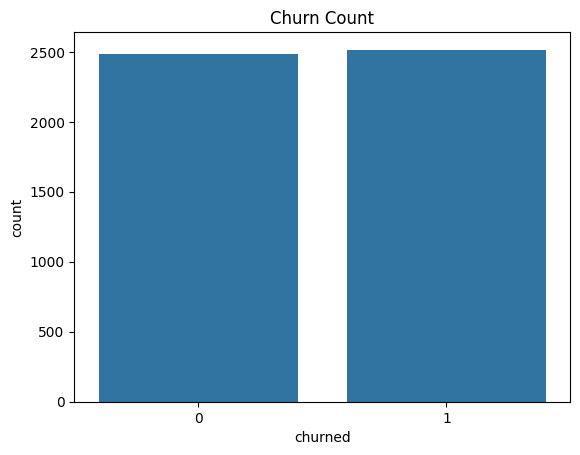

In [69]:

sns.countplot(x='churned', data=df)
plt.title("Churn Count")
plt.show()

In our dataset,we have the almost equal number of the churned and non-churned customers

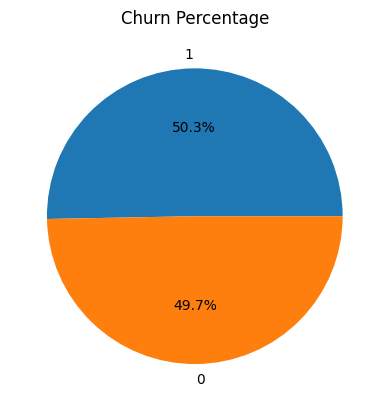

In [73]:
df['churned'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.ylabel('')
plt.show()

In the above graph,we notice that there is equal percentage of the churned and non-churned customer

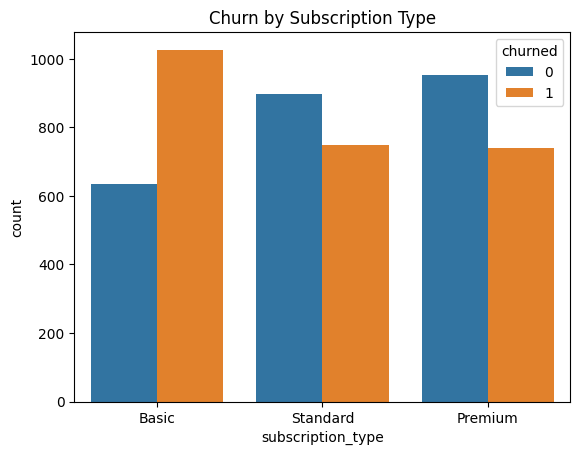

In [58]:
sns.countplot(data=df, x="subscription_type", hue="churned")
plt.title("Churn by Subscription Type")
plt.show()

from the above graph, we notice that the Basic subscription has more customers are churned then the standard and premium subscription.

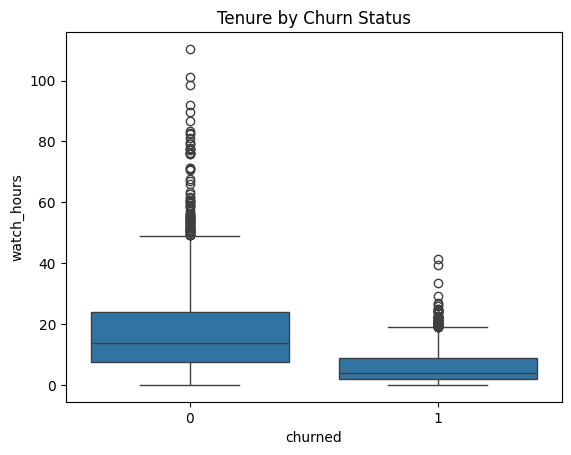

In [60]:
sns.boxplot(data=df, x="churned", y="watch_hours")
plt.title("Tenure by Churn Status")
plt.show()

Low usage → low engagement → churn

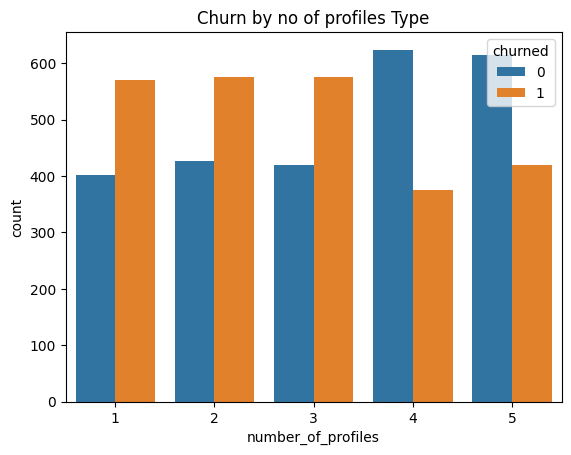

In [81]:
sns.countplot(data=df, x="number_of_profiles", hue="churned")
plt.title("Churn by no of profiles Type")
plt.show()

less number of profiles has more churned customers

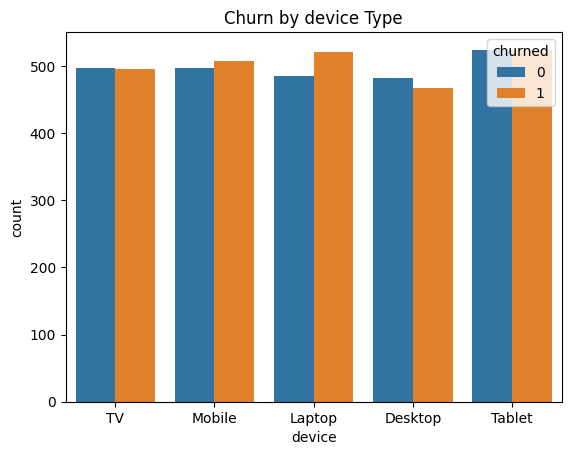

In [80]:
sns.countplot(data=df, x="device", hue="churned")
plt.title("Churn by device Type")
plt.show()

Desktop and tablet users are less churned we need to improve our services in the TV and Mobile

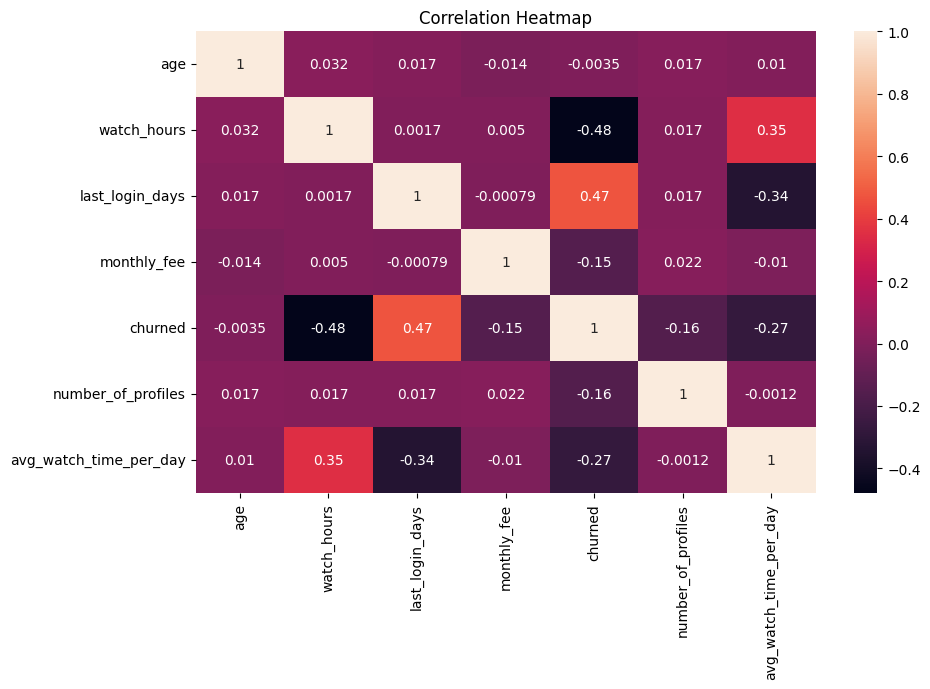

In [66]:
df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


watch hours and last login days has more effect the customer churns

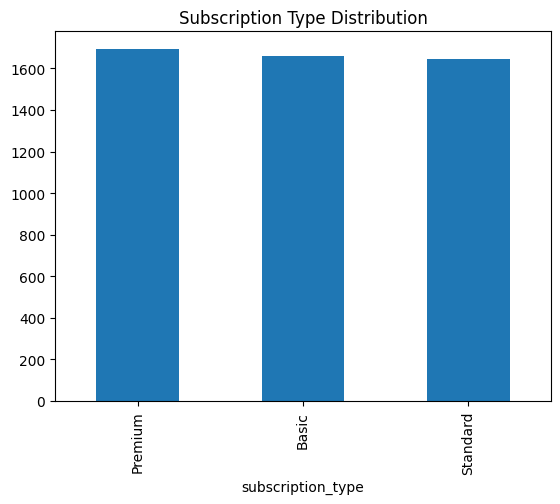

In [74]:
df['subscription_type'].value_counts().plot(kind='bar')
plt.title("Subscription Type Distribution")
plt.show()

It is also the balanced type,3 subscriptions types has the equal no of the customer

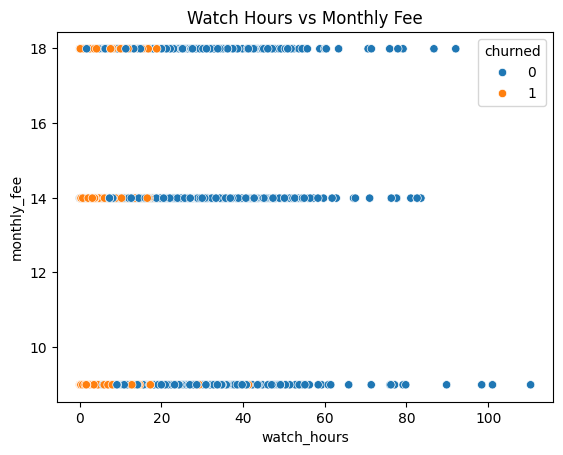

In [79]:
sns.scatterplot(x='watch_hours', y='monthly_fee', hue='churned', data=df)
plt.title("Watch Hours vs Monthly Fee")
plt.show()

high montly_fee and high watch_hours have less churned customers and less watch hours and less montly fee have more no of churned customer|

# Final insights

1. User Engagement is the Most Important Factor
Users with low watch hours are more likely to churn
Higher last_login_days (inactive users) → higher churn
Less daily usage → higher churn

2. Pricing Plays a Major Role
Users with higher monthly fees tend to churn more
Especially when their usage is low

3. Subscription Type Matters
Basic plan users show higher churn
Premium users are more stable and loyal

4. Account Sharing Reduces Churn
Users with more profiles (family usage) churn less
Single-user accounts have higher churn

5. Low Engagement + High Cost = High Risk
Users with:
Low watch time
High monthly fee
Inactive login
  These users are most likely to churn


# Recommondations

1. Improve User Engagement
Send personalized recommendations based on watch history
Use notifications/emails to bring back inactive users
Introduce “Continue Watching” reminders

 Goal: Increase watch time & reduce inactivity

 2. Target High-Risk Users Early
Identify users with:
Low watch time
High last login days
Offer discounts or free trials before they churn

 Goal: Prevent churn before it happens

3. Optimize Pricing Strategy
Provide flexible pricing plans
Offer discounts for low-usage users
Introduce usage-based plans

 Goal: Reduce churn due to high cost

 4. Improve Subscription Plans
Upgrade basic plan benefits
Provide trial upgrades to premium plans

 Goal: Move users to more stable plans

5. Encourage Family/Group Usage
Promote multi-profile plans
Offer family subscription discounts

Goal: Increase retention through shared usage